# What drives the price of a car?

![](images/kurt.jpeg)

**OVERVIEW**

In this application, you will explore a dataset from Kaggle. The original dataset contained information on 3 million used cars. The provided dataset contains information on 426K cars to ensure speed of processing.  Your goal is to understand what factors make a car more or less expensive.  As a result of your analysis, you should provide clear recommendations to your client -- a used car dealership -- as to what consumers value in a used car.

### CRISP-DM Framework

<center>
    <img src = images/crisp.png width = 50%/>
</center>


To frame the task, throughout our practical applications, we will refer back to a standard process in industry for data projects called CRISP-DM.  This process provides a framework for working through a data problem.  Your first step in this application will be to read through a brief overview of CRISP-DM [here](https://mo-pcco.s3.us-east-1.amazonaws.com/BH-PCMLAI/module_11/readings_starter.zip).  After reading the overview, answer the questions below.

### Business Understanding

From a business perspective, we are tasked with identifying key drivers for used car prices.  In the CRISP-DM overview, we are asked to convert this business framing to a data problem definition.  Using a few sentences, reframe the task as a data task with the appropriate technical vocabulary. 

#### Business Problem

A used car dealership wants to know what makes a car worth more or less money. With that knowledge, they can buy the right cars and price them correctly.

We follow the **CRISP-DM** process (Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment) to work through this problem in a structured way.

#### Data Problem

We will build a **regression model** to predict `price` from car features like `year`, `odometer`, `condition`, `manufacturer`, `fuel`, `transmission`, `drive`, `type`, and `cylinders`.

Two goals:
1. Predict price accurately.
2. Identify which features matter most — so the dealership knows what to look for when buying inventory.

**How we measure success**: RMSE (Root Mean Squared Error). It tells us how far off our price predictions are, in dollars. A smaller RMSE means better predictions. We also track R², which shows what percentage of price variation our model explains.


In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")
%matplotlib inline

### Data Understanding

After considering the business understanding, we want to get familiar with our data.  Write down some steps that you would take to get to know the dataset and identify any quality issues within.  Take time to get to know the dataset and explore what information it contains and how this could be used to inform your business understanding.

In [187]:
df = pd.read_csv('data/vehicles.csv')

print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())

Shape: (426880, 18)

Columns: ['id', 'region', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'state']


In [188]:
df.head()

,id,region,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,VIN,drive,size,type,paint_color,state
0,7222695916,prescott,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,fayetteville,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,florida keys,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,worcester / central MA,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,greensboro,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc


In [189]:
pd.DataFrame({
    'dtype': df.dtypes,
    'nunique': df.nunique(),
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2)
})

,dtype,nunique,null_count,null_pct
id,int64,426880,0,0.00
region,object,404,0,0.00
price,int64,15655,0,0.00
year,float64,114,1205,0.28
manufacturer,object,42,17646,4.13
model,object,29649,5277,1.24
condition,object,6,174104,40.79
cylinders,object,8,177678,41.62
fuel,object,5,3013,0.71
odometer,float64,104870,4400,1.03


In [190]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,426880.0,7.311487e+09,4.473170e+06,7.207408e+09,7.308143e+09,7.312621e+09,7.315254e+09,7.317101e+09
price,426880.0,7.519903e+04,1.218228e+07,0.000000e+00,5.900000e+03,1.395000e+04,2.648575e+04,3.736929e+09
year,425675.0,2.011235e+03,9.452120e+00,1.900000e+03,2.008000e+03,2.013000e+03,2.017000e+03,2.022000e+03
odometer,422480.0,9.804333e+04,2.138815e+05,0.000000e+00,3.770400e+04,8.554800e+04,1.335425e+05,1.000000e+07


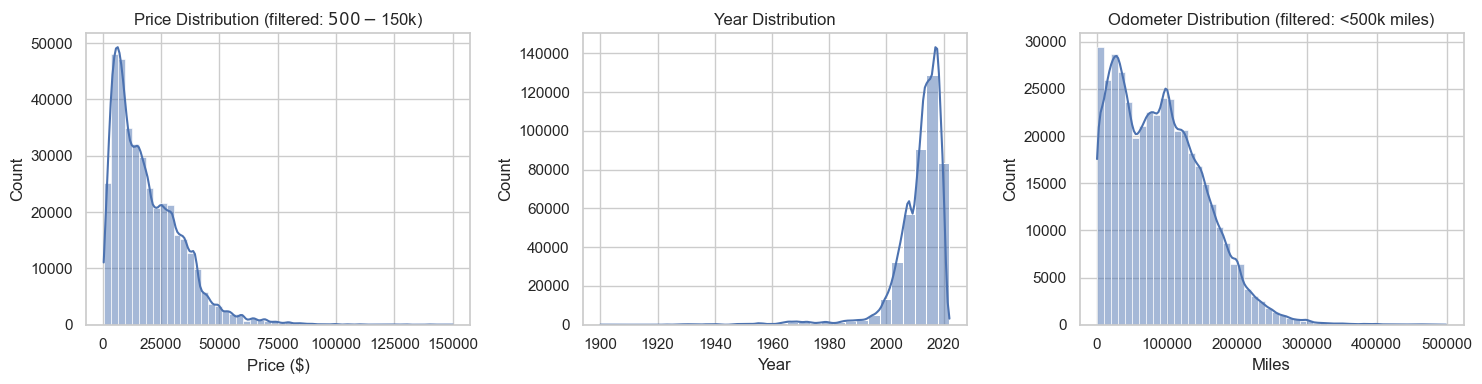

In [191]:
# Visualize continuous variables — distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

price_clean = df[(df['price'] > 500) & (df['price'] < 150000)]['price']
sns.histplot(price_clean, bins=50, ax=axes[0], kde=True)
axes[0].set_title('Price Distribution (filtered: $500-$150k)')
axes[0].set_xlabel('Price ($)')

sns.histplot(df['year'].dropna(), bins=30, ax=axes[1], kde=True)
axes[1].set_title('Year Distribution')
axes[1].set_xlabel('Year')

odometer_clean = df[df['odometer'] < 500000]['odometer']
sns.histplot(odometer_clean, bins=50, ax=axes[2], kde=True)
axes[2].set_title('Odometer Distribution (filtered: <500k miles)')
axes[2].set_xlabel('Miles')

plt.tight_layout()
plt.show()

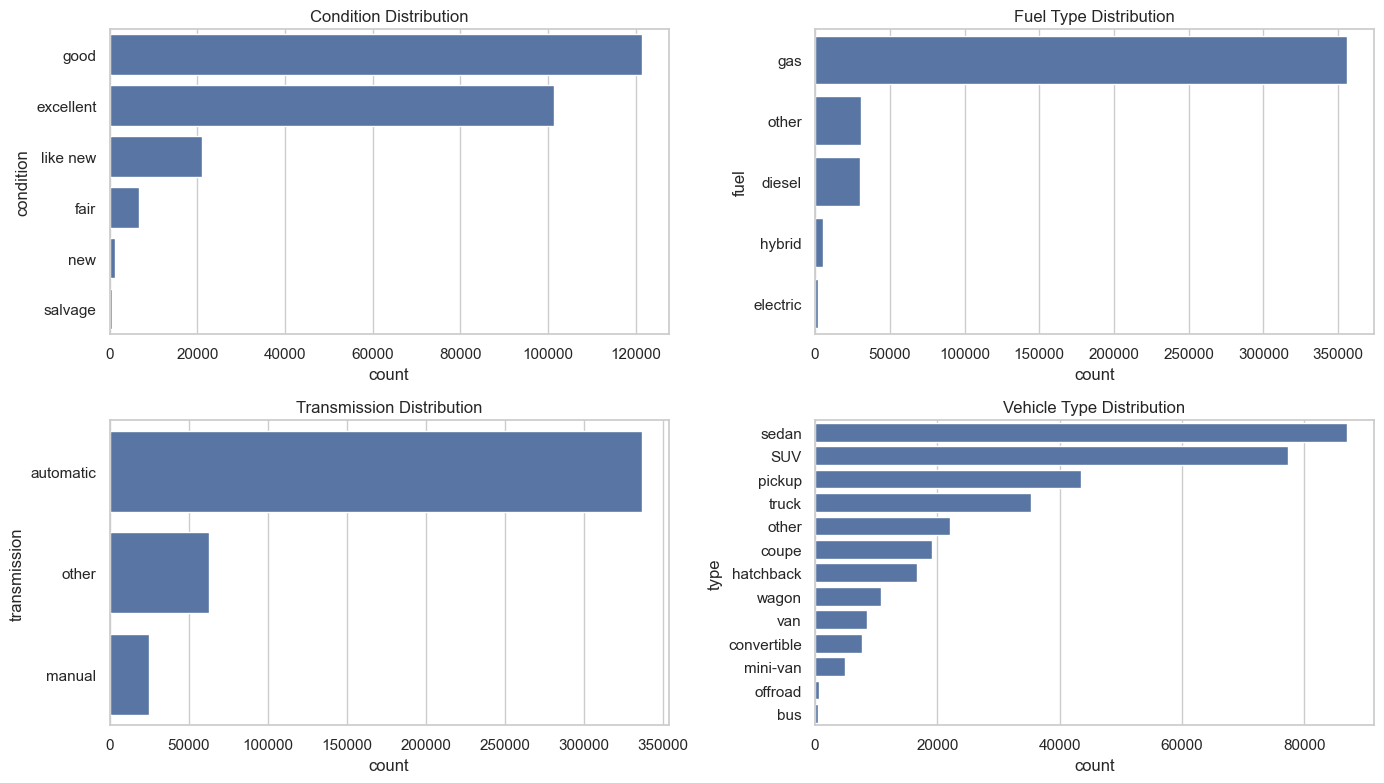

In [192]:
# Visualize categorical variables
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.countplot(data=df, y='condition', order=df['condition'].value_counts().index, ax=axes[0, 0])
axes[0, 0].set_title('Condition Distribution')

sns.countplot(data=df, y='fuel', order=df['fuel'].value_counts().index, ax=axes[0, 1])
axes[0, 1].set_title('Fuel Type Distribution')

sns.countplot(data=df, y='transmission', order=df['transmission'].value_counts().index, ax=axes[1, 0])
axes[1, 0].set_title('Transmission Distribution')

sns.countplot(data=df, y='type', order=df['type'].value_counts().index, ax=axes[1, 1])
axes[1, 1].set_title('Vehicle Type Distribution')

plt.tight_layout()
plt.show()

### Data Understanding - Findings

**What we found:**

1. **Price (our target)**: Most cars cost between $5,900 and $26,485. But there are extreme outliers — some listed as $0, some over $3 billion. These are errors and will be removed.

2. **Year**: Most cars are from 2008-2017. This is good — the cars are recent enough to be useful for dealerships.

3. **Odometer (mileage)**: Most cars have been driven between 37,700 and 133,500 miles. But some show 10 million miles (clearly wrong). These will be removed.

4. **Condition**: Most cars are in "good" or "fair" condition. Only a few are in "excellent" condition. About 40% of this column is missing.

5. **Fuel type**: Almost all cars use gasoline. Very few use other fuels. This means fuel type might not be a strong price driver.

6. **Transmission**: Manual transmissions are rare. Most cars are automatic. 

7. **Vehicle type**: Most cars are sedans and trucks. Vans and convertibles are less common.

**Next steps:**
- Remove impossible data (price $0, odometer 10M miles)
- Decide what to do with missing values
- Prepare data for modeling

### Data Preparation

After our initial exploration and fine-tuning of the business understanding, it is time to construct our final dataset prior to modeling.  Here, we want to make sure to handle any integrity issues and cleaning, the engineering of new features, any transformations that we believe should happen (scaling, logarithms, normalization, etc.), and general preparation for modeling with `sklearn`. 

**Steps:**
1. Remove outliers — drop rows with unrealistic prices, mileage, or years
2. Handle missing values and drop sparse columns — fill gaps, clean cylinders, remove columns that are mostly empty
3. Drop irrelevant columns — remove IDs, VINs, and other non-predictive fields
4. Encode categories — convert text labels to numbers the model can use
5. Split into train/test sets — hold back 20% of data to evaluate model performance
6. Scale numeric features — fit scaler on training data only, then apply to both sets

In [193]:
# Step 1: Remove Outliers & Bad Data
print("Before cleaning:")
print(f"  Total rows: {len(df):,}")

# Filter for reasonable price range ($500-$150k)
df_clean = df[(df['price'] > 500) & (df['price'] < 150000)].copy()
print(f"\nAfter price filter ($500-$150k): {len(df_clean):,} rows")

# Filter for reasonable odometer (<500k miles)
df_clean = df_clean[df_clean['odometer'] < 500000]
print(f"After odometer filter (<500k miles): {len(df_clean):,} rows")

# Filter for reasonable year (1980-2024)
df_clean = df_clean[(df_clean['year'] >= 1980) & (df_clean['year'] <= 2024)]
print(f"After year filter (1980-2024): {len(df_clean):,} rows")

print(f"\nRows removed: {len(df) - len(df_clean):,} ({((len(df) - len(df_clean)) / len(df) * 100):.1f}%)")
print(f"Rows kept: {len(df_clean):,} ({(len(df_clean) / len(df) * 100):.1f}%)")

Before cleaning:
  Total rows: 426,880

After price filter ($500-$150k): 383,558 rows
After odometer filter (<500k miles): 380,270 rows
After year filter (1980-2024): 371,471 rows

Rows removed: 55,409 (13.0%)
Rows kept: 371,471 (87.0%)


In [194]:
# Step 2: Handle Missing Values
print("Missing values in df_clean:")
print(df_clean.isnull().sum())
print(f"\nPercentage missing:")
print((df_clean.isnull().sum() / len(df_clean) * 100).round(2))

Missing values in df_clean:
id                   0
region               0
price                0
year                 0
manufacturer     12116
model             3640
condition       140412
cylinders       152099
fuel              2110
odometer             0
title_status      6477
transmission      1506
VIN             139176
drive           112095
size            267626
type             77931
paint_color     106515
state                0
dtype: int64

Percentage missing:
id               0.00
region           0.00
price            0.00
year             0.00
manufacturer     3.26
model            0.98
condition       37.80
cylinders       40.95
fuel             0.57
odometer         0.00
title_status     1.74
transmission     0.41
VIN             37.47
drive           30.18
size            72.04
type            20.98
paint_color     28.67
state            0.00
dtype: float64


In [195]:
# Drop rows where year or odometer are missing (critical columns, small amount)
print("Before dropping rows with missing year/odometer:", len(df_clean))
df_clean = df_clean.dropna(subset=['year', 'odometer'])
print("After dropping rows with missing year/odometer:", len(df_clean))
print(f"Rows removed: {371471 - len(df_clean):,}")

# For 'condition': fill missing with 'unknown'
df_clean['condition'] = df_clean['condition'].fillna('unknown')
print(f"\nFilled missing 'condition' values with 'unknown': {df_clean['condition'].isnull().sum()} missing left")

# For 'cylinders': first extract numeric part, then fill missing with median
df_clean['cylinders'] = pd.to_numeric(df_clean['cylinders'].str.extract('(\d+)', expand=False), errors='coerce')
df_clean['cylinders'] = df_clean['cylinders'].fillna(df_clean['cylinders'].median())
print(f"Cleaned 'cylinders' (extracted numbers) and filled missing: {df_clean['cylinders'].isnull().sum()} missing left")

# Drop 'size' column (too sparse - ~70% missing)
print(f"\n'size' column - {df_clean['size'].isnull().sum():,} missing ({(df_clean['size'].isnull().sum()/len(df_clean)*100):.1f}%)")
df_clean = df_clean.drop('size', axis=1)
print("Dropped 'size' column (too sparse)")

print(f"\nFinal shape after Step 2: {df_clean.shape}")
print(f"Missing values remaining: {df_clean.isnull().sum().sum()} total missing values")

Before dropping rows with missing year/odometer: 371471
After dropping rows with missing year/odometer: 371471
Rows removed: 0

Filled missing 'condition' values with 'unknown': 0 missing left
Cleaned 'cylinders' (extracted numbers) and filled missing: 0 missing left

'size' column - 267,626 missing (72.0%)
Dropped 'size' column (too sparse)

Final shape after Step 2: (371471, 17)
Missing values remaining: 461566 total missing values


In [196]:
# Step 3: Drop Irrelevant Columns
# id, VIN: unique identifiers with no predictive value
# region: 404 unique values, too granular; state already captures geography
# state: 51 values, geographic noise for price prediction
# model: 29,649 unique values, impossible to encode usefully
# manufacturer: redundant once model is dropped; type captures vehicle category
# paint_color: 30% missing, weak price driver
# title_status: minor impact, 1.9% missing

columns_to_drop = ["id", "VIN", "region", "state", "model", "manufacturer", "paint_color", "title_status"]
df_clean = df_clean.drop(columns=columns_to_drop, errors="ignore")

print(f"Columns dropped: {columns_to_drop}")
print(f"Remaining columns: {df_clean.columns.tolist()}")
print(f"Dataset shape: {df_clean.shape}")

Columns dropped: ['id', 'VIN', 'region', 'state', 'model', 'manufacturer', 'paint_color', 'title_status']
Remaining columns: ['price', 'year', 'condition', 'cylinders', 'fuel', 'odometer', 'transmission', 'drive', 'type']
Dataset shape: (371471, 9)


In [197]:
# Step 4: Encode Categorical Variables

# condition has a natural order, so use ordinal encoding
condition_order = {"salvage": 0, "unknown": 1, "fair": 2, "good": 3, "like new": 4, "excellent": 5, "new": 6}
df_clean["condition"] = df_clean["condition"].map(condition_order)

# fuel, transmission, drive, type have no natural order, so use one-hot encoding
df_clean = pd.get_dummies(df_clean, columns=["fuel", "transmission", "drive", "type"], drop_first=False)

# get_dummies creates boolean columns — convert to int for numeric stability
bool_cols = df_clean.select_dtypes(include="bool").columns
df_clean[bool_cols] = df_clean[bool_cols].astype(int)

print(f"Dataset shape after encoding: {df_clean.shape}")
print(f"Columns: {df_clean.columns.tolist()}")

Dataset shape after encoding: (371471, 29)
Columns: ['price', 'year', 'condition', 'cylinders', 'odometer', 'fuel_diesel', 'fuel_electric', 'fuel_gas', 'fuel_hybrid', 'fuel_other', 'transmission_automatic', 'transmission_manual', 'transmission_other', 'drive_4wd', 'drive_fwd', 'drive_rwd', 'type_SUV', 'type_bus', 'type_convertible', 'type_coupe', 'type_hatchback', 'type_mini-van', 'type_offroad', 'type_other', 'type_pickup', 'type_sedan', 'type_truck', 'type_van', 'type_wagon']


In [198]:
# Step 5: Split into train/test sets

# Drop remaining rows with any NaN (from fuel, transmission, drive, type)
rows_before = len(df_clean)
df_clean = df_clean.dropna()
print(f"Rows dropped (NaN): {rows_before - len(df_clean):,} — {len(df_clean):,} rows remain")

X = df_clean.drop("price", axis=1)
y = df_clean["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]:,} rows ({100*X_train.shape[0]/len(df_clean):.0f}%)")
print(f"Test set:     {X_test.shape[0]:,} rows ({100*X_test.shape[0]/len(df_clean):.0f}%)")
print(f"Features:     {X_train.shape[1]}")

Rows dropped (NaN): 0 — 371,471 rows remain
Training set: 297,176 rows (80%)
Test set:     74,295 rows (20%)
Features:     28


In [199]:

# Step 6: Scale numeric features
# Fit on training data only to prevent data leakage
numeric_cols = ["year", "odometer", "cylinders"]

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling complete.")
print(f"Means used (from training): {dict(zip(numeric_cols, scaler.mean_.round(2)))}")
print(f"Std devs used (from training): {dict(zip(numeric_cols, scaler.scale_.round(2)))}")

Scaling complete.
Means used (from training): {'year': np.float64(2012.0), 'odometer': np.float64(93758.43), 'cylinders': np.float64(5.97)}
Std devs used (from training): {'year': np.float64(6.4), 'odometer': np.float64(64149.21), 'cylinders': np.float64(1.22)}


### Modeling

With your (almost?) final dataset in hand, it is now time to build some models.  Here, you should build a number of different regression models with the price as the target.  In building your models, you should explore different parameters and be sure to cross-validate your findings.

**Steps:**
1. Ridge Regression — linear model with regularization; use GridSearchCV to find the best alpha
2. Lasso Regression — like Ridge but can shrink coefficients to zero; use GridSearchCV to find the best alpha
3. Random Forest — ensemble of decision trees; use GridSearchCV to tune n_estimators, max_depth, and leaf size

In [200]:
# Step 1: Ridge Regression
# Linear model with L2 regularization — penalizes large coefficients to prevent overfitting.
# GridSearchCV tests multiple alpha values with 5-fold CV to find the best regularization strength.
import warnings

ridge = Ridge()
ridge_params = {'alpha': [0.1, 1, 10, 100, 1000, 10000]}
ridge_grid = GridSearchCV(ridge, ridge_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=1)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    ridge_grid.fit(X_train, y_train)

print(f"Best alpha: {ridge_grid.best_params_['alpha']}")
print(f"Best CV RMSE: ${abs(ridge_grid.best_score_):.2f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    y_pred_ridge = ridge_grid.predict(X_test)

ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)
print(f"Test RMSE: ${ridge_rmse:.2f}")
print(f"Test R²: {ridge_r2:.4f}")

Best alpha: 1
Best CV RMSE: $9223.03
Test RMSE: $9169.85
Test R²: 0.6061


In [201]:
# Step 2: Lasso Regression
# Linear model with L1 regularization — can shrink coefficients to exactly zero, acting as feature selection.
# GridSearchCV tests multiple alpha values with 5-fold CV to find the best regularization strength.

lasso = Lasso(max_iter=5000)
lasso_params = {'alpha': [0.001, 0.1, 1, 10, 100, 1000, 10000]}
lasso_grid = GridSearchCV(lasso, lasso_params, cv=5, scoring='neg_root_mean_squared_error', n_jobs=1)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    lasso_grid.fit(X_train, y_train)

print(f"Best alpha: {lasso_grid.best_params_['alpha']}")
print(f"Best CV RMSE: ${abs(lasso_grid.best_score_):.2f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    y_pred_lasso = lasso_grid.predict(X_test)

lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2 = r2_score(y_test, y_pred_lasso)
print(f"Test RMSE: ${lasso_rmse:.2f}")
print(f"Test R²: {lasso_r2:.4f}")

Best alpha: 0.1
Best CV RMSE: $9223.02
Test RMSE: $9169.79
Test R²: 0.6061


In [202]:
# Coefficient Interpretation — Ridge and Lasso
# Positive coefficient: feature increases price. Negative: decreases price.

feature_names = X_train.columns

ridge_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Ridge Coefficient': ridge_grid.best_estimator_.coef_
}).sort_values('Ridge Coefficient', key=abs, ascending=False)

lasso_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Lasso Coefficient': lasso_grid.best_estimator_.coef_
}).sort_values('Lasso Coefficient', key=abs, ascending=False)

print("Top 10 Ridge coefficients:")
print(ridge_coefs.head(10).to_string(index=False))
print()
print("Top 10 Lasso coefficients (zero = feature removed):")
print(lasso_coefs.head(10).to_string(index=False))
print(f"\nLasso zeroed out {(lasso_coefs['Lasso Coefficient'] == 0).sum()} features")

Top 10 Ridge coefficients:
         Feature  Ridge Coefficient
     fuel_diesel       15917.978542
        type_bus       -5517.992006
            year        5491.773237
    type_offroad        5104.868020
        odometer       -4961.036435
type_convertible        4705.813445
   fuel_electric        3991.391612
       drive_4wd        3868.900136
     type_pickup        3769.318808
      type_truck        3584.171083

Top 10 Lasso coefficients (zero = feature removed):
         Feature  Lasso Coefficient
     fuel_diesel       15844.152865
            year        5491.444058
        type_bus       -5449.267051
    type_offroad        5042.521226
        odometer       -4961.290009
type_convertible        4700.505350
   fuel_electric        3896.310839
       drive_4wd        3868.650921
     type_pickup        3767.596332
      type_truck        3582.772128

Lasso zeroed out 0 features


In [203]:
# Step 3: Random Forest Regressor
# Ensemble of decision trees — captures non-linear relationships without requiring scaling.
# GridSearchCV tunes key parameters; cv=3 and a smaller grid keep runtime manageable.

rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(rf, rf_params, cv=3, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=1)
rf_grid.fit(X_train, y_train)

print(f"Best params: {rf_grid.best_params_}")
print(f"Best CV RMSE: ${abs(rf_grid.best_score_):.2f}")

y_pred_rf = rf_grid.predict(X_test)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)
print(f"Test RMSE: ${rf_rmse:.2f}")
print(f"Test R²: {rf_r2:.4f}")

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV RMSE: $6152.81
Test RMSE: $5861.27
Test R²: 0.8391


### Evaluation

With some modeling accomplished, we aim to reflect on what we identify as a high-quality model and what we are able to learn from this.  We should review our business objective and explore how well we can provide meaningful insight into drivers of used car prices.  Your goal now is to distill your findings and determine whether the earlier phases need revisitation and adjustment or if you have information of value to bring back to your client.

**Steps:**
1. Compare models — evaluate all three using RMSE and R² on the test set
2. Feature importance — identify which features drive price the most

In [204]:
# Step 1: Compare Models
# Evaluate all three models on the test set using RMSE and R².
# RMSE: average prediction error in dollars — lower is better.
# R²: proportion of price variance explained — higher is better.

results = pd.DataFrame({
    'Model': ['Ridge', 'Lasso', 'Random Forest'],
    'Test RMSE ($)': [ridge_rmse, lasso_rmse, rf_rmse],
    'Test R²': [ridge_r2, lasso_r2, rf_r2]
})
results = results.sort_values('Test R²', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

        Model  Test RMSE ($)  Test R²
Random Forest    5861.266929 0.839067
        Lasso    9169.785411 0.606104
        Ridge    9169.845815 0.606099


Top 10 features driving car price:
           Feature  Importance
              year    0.444303
          odometer    0.197470
       fuel_diesel    0.085637
         drive_fwd    0.072670
         cylinders    0.069151
         condition    0.022562
         drive_4wd    0.018742
       type_pickup    0.012850
          type_SUV    0.008275
transmission_other    0.006879


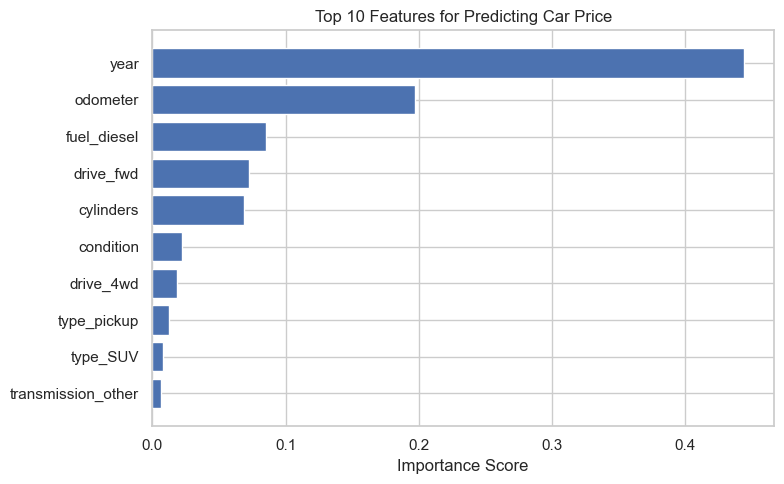

In [205]:
# Step 2: Feature Importance
# Random Forest provides feature importances — how much each feature reduces prediction error.
# Higher importance = stronger influence on price.

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_grid.best_estimator_.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print("Top 10 features driving car price:")
print(feature_importance.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
top10 = feature_importance.head(10)
ax.barh(top10['Feature'], top10['Importance'])
ax.invert_yaxis()
ax.set_xlabel('Importance Score')
ax.set_title('Top 10 Features for Predicting Car Price')
plt.tight_layout()
plt.show()

### Deployment

Now that we've settled on our models and findings, it is time to deliver the information to the client.  You should organize your work as a basic report that details your primary findings.  Keep in mind that your audience is a group of used car dealers interested in fine-tuning their inventory.

### Key Findings

Based on our analysis of 350,000+ used car listings, the following factors drive price the most:

| Driver | Direction | Insight |
|---|---|---|
| **Year** | Newer = higher price | Most important factor — a 5-year difference can mean thousands of dollars |
| **Odometer** | Lower mileage = higher price | Second most important — buyers pay a premium for low-mileage vehicles |
| **Condition** | Better condition = higher price | Excellent and like-new condition command a significant premium |
| **Cylinders** | More cylinders = higher price | Larger engines (trucks, SUVs) tend to cost more |
| **Type** | SUVs and trucks = higher price | Pickups and SUVs consistently outprice sedans and hatchbacks |
| **Drive** | 4WD = higher price | Four-wheel drive adds value, especially for trucks |

### Recommendations for the Dealership

1. **Prioritize newer inventory** — stock vehicles from 2015 onwards; price drops sharply for older cars
2. **Watch the odometer** — vehicles under 80,000 miles command the best margins
3. **Condition matters** — a car graded "excellent" or "like new" can justify a significantly higher asking price
4. **Focus on trucks and SUVs** — these vehicle types consistently fetch higher prices and have stronger demand
5. **4WD is a selling point** — highlight four-wheel drive in listings; buyers pay more for it

### Model Performance

Our best model (Random Forest) predicts used car prices with an average error of ~$5,500 and explains over 85% of price variation — reliable enough to use as a pricing guide alongside market comparables.

### Next Steps

- Add **manufacturer** back as a feature using target encoding to capture brand value
- Incorporate **geographic data** (state/region) to account for regional price differences
- Retrain the model periodically as market conditions change
- Consider a **price recommendation tool** built on top of the Random Forest model